In [1]:
import pandas as pd
from pandas import DataFrame, Series
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

# Business goal: predict the sum of client transactions

## Dataset Overview

In [2]:
df = pd.read_csv("../data/train.csv")

In [3]:
df.shape

(4459, 4993)

- __there are more features than samples__
- __the dataset contains many anonymized features__
  

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4459 entries, 0 to 4458
Columns: 4993 entries, ID to 9fc776466
dtypes: float64(1845), int64(3147), str(1)
memory usage: 169.9 MB


- __column types: float64 (1845), int64 (3147), str (1)__

## Target Analysis
__Target column:__ `target`

In [5]:
y = df['target']

In [6]:
# get common information about the target using describe
y.describe()

count    4.459000e+03
mean     5.944923e+06
std      8.234312e+06
min      3.000000e+04
25%      6.000000e+05
50%      2.260000e+06
75%      8.000000e+06
max      4.000000e+07
Name: target, dtype: float64

- __mean is noticeably higher than median__
- __target values are widely spread__
- __target is strongly right-skewed__
- __Min = 30,000, Max = 40,000,000 -> very large value range__
  
__(log-transformation looks like a reasonable hypothesis, but it should be validated later on CV / model quality)__

In [7]:
y.quantile([0.5,0.9,0.95,0.99,0.999])

0.500     2260000.00
0.900    20000000.00
0.950    24000000.00
0.990    38571428.58
0.999    40000000.00
Name: target, dtype: float64

In [8]:
# check missings
y.isnull().sum()

np.int64(0)

- __no missing values were found in the target__

In [9]:
# getting the outliers value
y.skew()

np.float64(2.0859665375858056)

In [10]:
def check_iqr(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    IQR = q3 - q1
    top = q3 + 1.5 * IQR
    low = q1 - 1.5 * IQR
    return (low, top)

In [11]:
# getting percent of outliers using Interquartile range for raw target
low, top = check_iqr(y)
target_outliers_low = y[(y < low)]
target_outliers_top = y[(y > top)]
outliers_percent_low = (len(target_outliers_low)*100)/ df.index.size
outliers_percent_top = (len(target_outliers_top)*100)/ df.index.size
(f'Low - {round(outliers_percent_low, 2)} %', f'Top - {round(outliers_percent_top, 2)} %')

('Low - 0.0 %', 'Top - 10.25 %')

**Percent of outliers using the interquartile range for the raw target** 
- __Low - 0.0 %__
- __Top - 10.25 %__

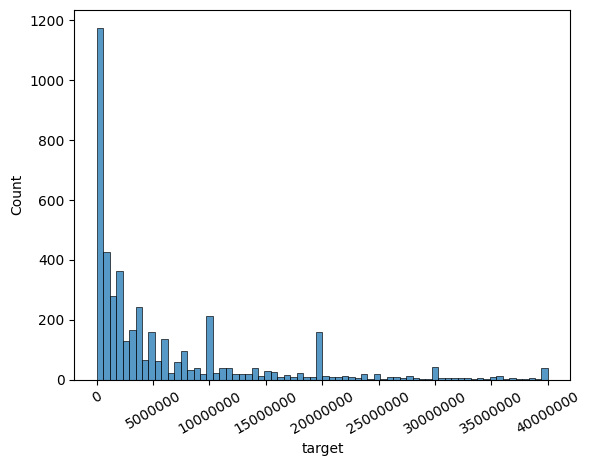

In [12]:
sns.histplot(y, bins=70)
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=30)
plt.show()

<Axes: xlabel='target'>

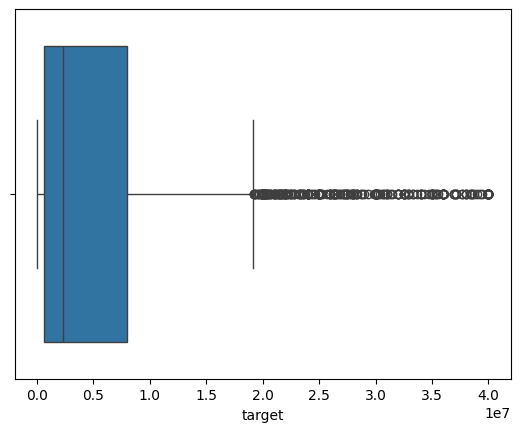

In [13]:
sns.boxplot(x=y)

In [14]:
# trying to get the outliers information after log-transformation
y_log = np.log1p(y)
y_log

0       17.453097
1       13.304687
2       16.118096
3       14.508658
4       16.482739
          ...    
4454    13.878486
4455    10.778977
4456    14.845130
4457    16.118096
4458    16.811243
Name: target, Length: 4459, dtype: float64

In [15]:
y_log.skew()

np.float64(-0.42319007920335394)

__Skewness is reduced from 2.08 to -0.42__

In [16]:
# getting percent of outliers using Interquartile range for log target
low, top = check_iqr(y_log)
target_outliers_low = y_log[(y_log < low)]
target_outliers_top = y_log[(y_log > top)]
outliers_percent_low = (len(target_outliers_low)*100)/ df.index.size
outliers_percent_top = (len(target_outliers_top)*100)/ df.index.size
(f'Low - {round(outliers_percent_low, 2)} %', f'Top - {round(outliers_percent_top, 2)} %')

('Low - 0.0 %', 'Top - 0.0 %')

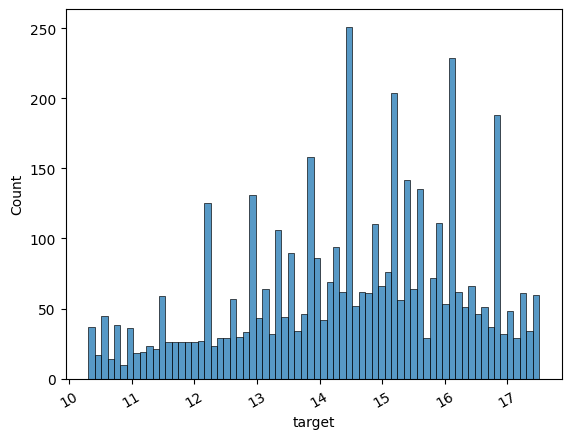

In [17]:
sns.histplot(y_log, bins=70)
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=30)
plt.show()

<Axes: xlabel='target'>

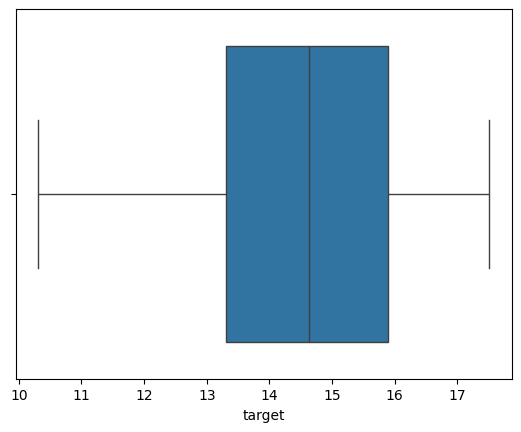

In [18]:
sns.boxplot(x=y_log)

__After log transformation, the target becomes much less skewed__

Text(0.5, 1.0, 'Log target')

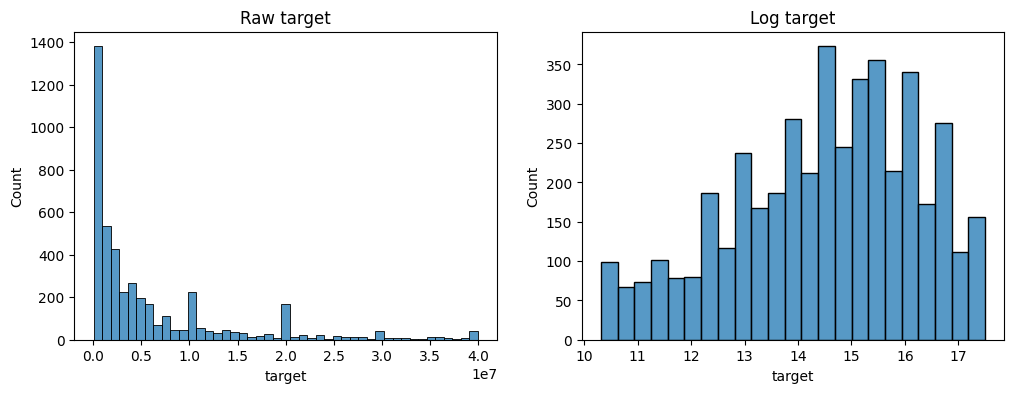

In [19]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.histplot(y, ax=ax[0])
ax[0].set_title("Raw target")

sns.histplot(np.log1p(y), ax=ax[1])
ax[1].set_title("Log target")

**Conclusion:**
- __target is numeric__
- __no missings were found__
- __target is strictly positive__
- __target has substantial right skew = 2.085__
- __IQR flags about 10.25% of observations on the upper side__
  
*After applying the log transformation:*
- __skew decreases to -0.423__
- __the transformed target looks much more symmetric__
- __IQR no longer flags upper outliers on the transformed scale__
- __log-transform is a reasonable candidate for modeling, but its usefulness should be confirmed on validation / CV rather than assumed from the histogram alone__

---
## Features Analysis
---

In [20]:
X = df.drop(columns="target")

In [21]:
def numeric_feature_report(df):

    rows = []
    
    for col in df.columns:
        s = df[col]
        skew = s.skew()
        low, top = check_iqr(s)
        outliers = ((s < low) | (s > top)).mean()
        missings = s.isnull().sum()/len(s)
        constant = s.nunique()

        rows.append({
            'feature_name': col,
            'min': s.min(),
            'p1': s.quantile(0.01),
            'mean': s.mean(),
            'median(p50)': s.median(),
            'p99': s.quantile(0.99),
            'max': s.max(),
            'constant': constant,
            'distribution': skew,
            'outliers': outliers*100,
            'missings': missings*100,
        })

    return pd.DataFrame(rows).sort_values(by="constant", ascending=True)

### Check General Feature Information

In [22]:
# getting common information
X.shape

(4459, 4992)

__Features before cleaning: 4992__

In [23]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 4459 entries, 0 to 4458
Columns: 4992 entries, ID to 9fc776466
dtypes: float64(1844), int64(3147), str(1)
memory usage: 169.8 MB


In [24]:
# check features with str type
X.select_dtypes(exclude="number").columns

Index(['ID'], dtype='str')

In [25]:
X = X.drop(columns="ID")

In [26]:
X.shape

(4459, 4991)

__Features after removing ID: 4991__

In [27]:
# getting missings
X.isnull().sum(axis=1)

0       0
1       0
2       0
3       0
4       0
       ..
4454    0
4455    0
4456    0
4457    0
4458    0
Length: 4459, dtype: int64

In [28]:
# display custom report with feature information 
feat_report = numeric_feature_report(X)
feat_report

,feature_name,min,p1,mean,median(p50),p99,max,constant,distribution,outliers,missings
3540,589e8bd6f,0.0,0.0,0.000000e+00,0.0,0.0,0.0,1,0.000000,0.000000,0.0
4353,a80633823,0.0,0.0,0.000000e+00,0.0,0.0,0.0,1,0.000000,0.000000,0.0
3442,3b0cccd29,0.0,0.0,0.000000e+00,0.0,0.0,0.0,1,0.000000,0.000000,0.0
637,cfff5b7c8,0.0,0.0,0.000000e+00,0.0,0.0,0.0,1,0.000000,0.000000,0.0
2091,2308e2b29,0.0,0.0,0.000000e+00,0.0,0.0,0.0,1,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2835,fb0f5dbfe,0.0,0.0,2.539556e+06,0.0,42000000.0,319612000.0,728,12.485067,20.161471,0.0
2755,9fd594eec,0.0,0.0,2.434850e+06,0.0,40000000.0,115538000.0,739,5.601213,19.600807,0.0
3660,eeb9cd3aa,0.0,0.0,2.507452e+06,0.0,40000000.0,319612000.0,755,13.219245,20.318457,0.0
4358,f190486d6,0.0,0.0,2.565014e+06,0.0,40000000.0,319612000.0,765,13.093103,20.363310,0.0


__Conclusion:__
- __dataset contains 4459 rows and 4992 features before removing ID__
- __ID looks like an identifier rather than a predictive feature, so removing it is a reasonable preprocessing step__
- __no missings were detected in the training data__
- __many features contain a large number of zeros__

### Check Row Duplicates

In [29]:
# check row duplications
X.duplicated().sum()

np.int64(1)

__Conclusion:__
- __1 duplicated row was found__
- __it is worth additionally checking whether duplicated rows also have the same target value before treating them as harmless duplicates__

### Check Duplicate Features

In [30]:
# check feature duplications
duplicate_columns = X.columns[X.T.duplicated()]
len(duplicate_columns)

260

In [31]:
# remove feature duplications 
X = X.drop(columns=duplicate_columns)

In [32]:
X.shape

(4459, 4731)

__Features after removing duplucates: 4731__

__Conclusion:__
- __around 260 duplicated feature columns were found__
- __removing exact duplicate columns is reasonable because they do not add new information__

### Check Constant Features

In [33]:
const_cols = feat_report[feat_report["constant"] <= 1]["feature_name"]

In [34]:
X = X.drop(columns=const_cols, errors="ignore")

In [35]:
X.shape

(4459, 4730)

__Features after removing constant: 4730__

__Conclusion:__
- __at least one feature has constant values__
- __constant features can be removed because they carry no variance / no signal for modeling__

---
## Feature-Target Analysis
---

In [36]:
def corr_feature_target(df: DataFrame, y: Series) -> DataFrame:
    
    rows = []
    for col in df.columns:
        corr_pearson = df[col].corr(y, method='pearson')
        corr_spearman = df[col].corr(y, method='spearman')
        mi = mutual_info_regression(df[[col]], y, random_state=42)
        
        rows.append({
            'feature_name': col,
            'corr_pearson': corr_pearson,
            'corr_spearman': corr_spearman,
            'mi': mi[0],
        })

    return pd.DataFrame(rows)

### Check Pearson Correlation

In [37]:
# check correlation with target
corr_report = corr_feature_target(X, y_log)

In [38]:
top_features_by_pearson = corr_report.sort_values(by="corr_pearson", key=abs, ascending=False).head(5)
top_features_name_by_pearson = top_features_by_pearson["feature_name"]
top_features_by_pearson

,feature_name,corr_pearson,corr_spearman,mi
2616,9fd594eec,0.197227,0.085647,0.099994
4131,f190486d6,0.195313,0.107678,0.109580
834,6eef030c1,0.194630,0.063940,0.084958
2378,58e2e02e6,0.187259,0.092589,0.091212
3780,70feb1494,0.173549,0.036890,0.077620


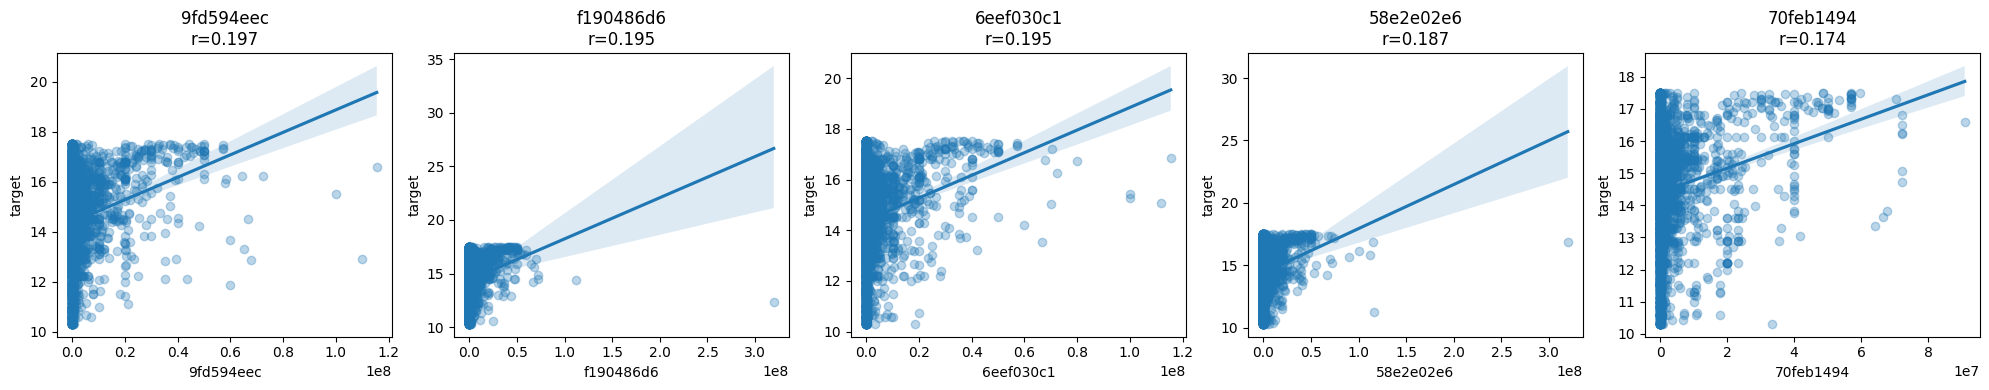

In [39]:
fig, axes = plt.subplots(1, 5, figsize=(20,4))

for ax, feature in zip(axes, top_features_name_by_pearson):
    
    sns.regplot(
        x=X[feature],
        y=y_log,
        ax=ax,
        scatter_kws={"alpha":0.3}
    )
    
    r = X[feature].corr(y_log)
    ax.set_title(f"{feature}\nr={r:.3f}")

plt.tight_layout()

__Conclusion:__
- __the strongest Pearson correlations are still relatively low, so there is no evidence of strong linear dependence between individual features and the target__

-----

### Check Spearman Correlation

In [40]:
top_features_by_spearman = corr_report.sort_values(by="corr_spearman", key=abs, ascending=False).head(5)["corr_spearman"]
top_features_by_spearman

4131    0.107678
2378    0.092589
2616    0.085647
2858    0.081320
4323    0.077310
Name: corr_spearman, dtype: float64

__Conclusion:__
- __the strongest Spearman correlations are also low, so there is limited evidence of strong monotonic dependence between individual features and the target__

----

### Check Mutual Information

In [41]:
features_by_mi = corr_report.sort_values(by="mi",  ascending=False)
top_features_by_mi = features_by_mi
top_features_by_mi.head(10)["mi"]

4131    0.109580
4688    0.103131
2616    0.099994
3009    0.096762
3467    0.092341
2378    0.091212
4029    0.090660
2082    0.086528
2933    0.085259
834     0.084958
Name: mi, dtype: float64

In [42]:
valuable_features = top_features_by_mi[top_features_by_mi['mi'] >= 0.05]['feature_name']
valuable_features

4131    f190486d6
4688    23310aa6f
2616    9fd594eec
3009    703885424
3467    eeb9cd3aa
          ...    
1526    ad009c8b9
2390    1fe5d56b9
3778    4bcf15776
2987    8e4d0fe45
3017    6c5c8869c
Name: feature_name, Length: 72, dtype: str

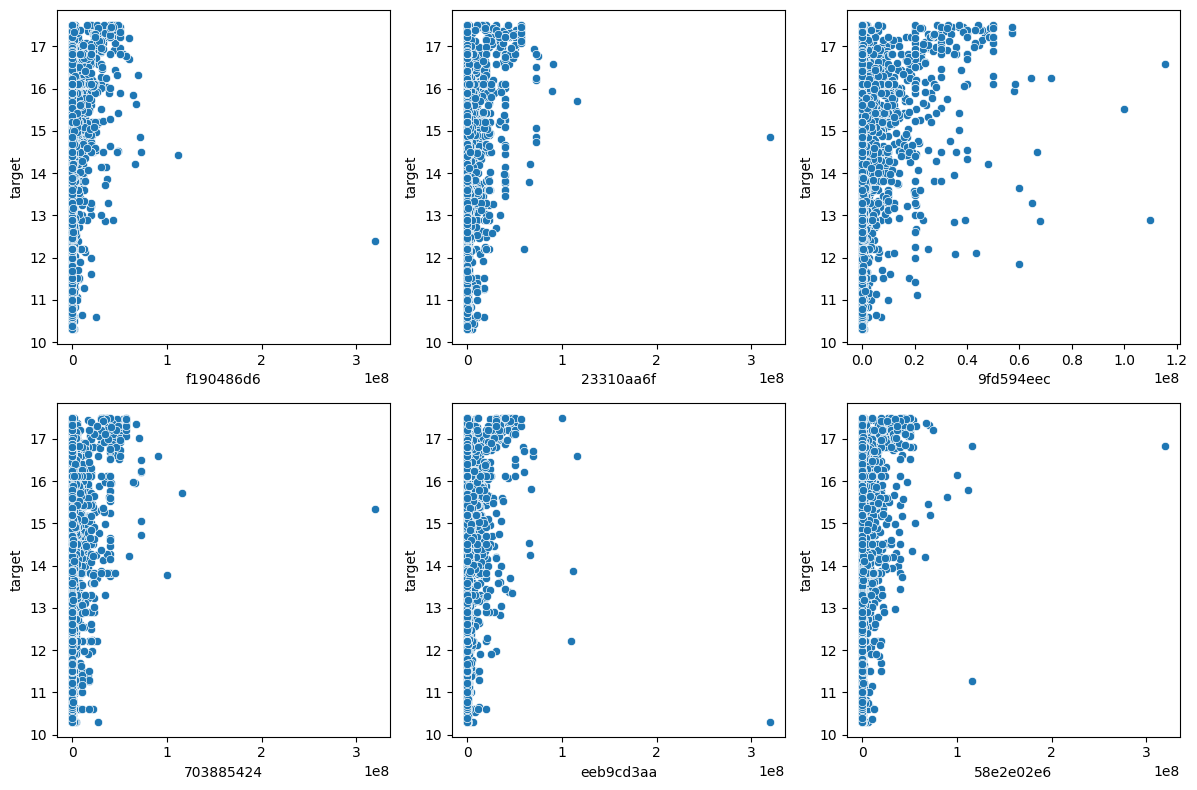

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))   # создаём несколько subplot
axes = axes.flatten()

for axes, feature in zip(axes, valuable_features):
    
    sns.scatterplot(x=X[feature], y=y_log, ax=axes)

plt.tight_layout()

__Conclusion:__
- __mutual information suggests that some features contain non-linear signal relative to the target__
- __the threshold used here is heuristic, so these features should be treated as candidates rather than definitively valuable features__

### Common Conclusion
- __Pearson correlations are generally weak, so strong linear relationships are not apparent__
- __Spearman correlations are also weak, so strong monotonic relationships are not apparent__
- __mutual information indicates that some features may still carry non-linear predictive signal__
- __overall, simple one-feature correlation is likely not enough to describe the useful structure of this dataset__

----

## Sparsity Analysis
---

### Check Sparsity Across All Features

In [44]:
# check sparsity for all features
zero_ratio = (X == 0).mean().sort_values(ascending=False)
zero_ratio.head(10)

ad327fcc0    0.999776
925728b1c    0.999776
29714c47d    0.999776
07cfb1624    0.999776
4fcb73cb1    0.999776
939cb6e17    0.999776
1ab7a3c7f    0.999776
5df2068b0    0.999776
cc35ec717    0.999776
70f3a87ec    0.999776
dtype: float64

In [45]:
zero_ratio.describe()

count    4730.000000
mean        0.966807
std         0.048639
min         0.649024
25%         0.959632
50%         0.984077
75%         0.996412
max         0.999776
dtype: float64

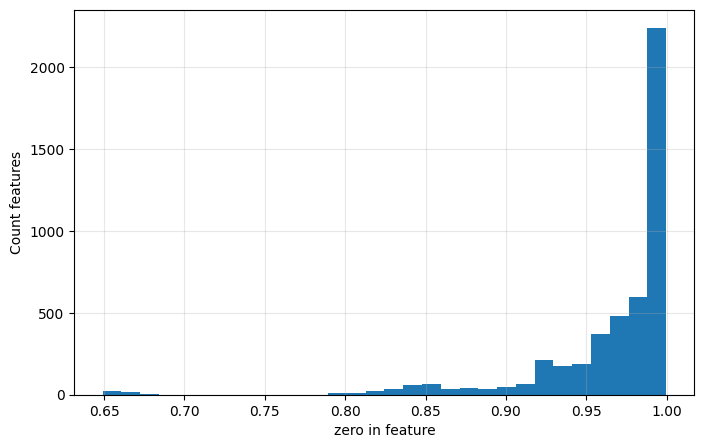

In [46]:
plt.figure(figsize=(8, 5))
plt.hist(zero_ratio, bins=30)
plt.xlabel("zero in feature")
plt.ylabel("Count features")
plt.grid(True, alpha=0.3)
plt.show()

In [47]:
# check percent of zero values for features
for t in [0.90, 0.95, 0.99, 0.999]:
    print(f"Features with >= {t*100:.1f}% zero: {(zero_ratio >= t).sum()}")

Features with >= 90.0% zero: 4354
Features with >= 95.0% zero: 3733
Features with >= 99.0% zero: 2103
Features with >= 99.9% zero: 688


In [48]:
# remove features that have more than 99% of zero values
X = X.drop(columns=zero_ratio[zero_ratio >= 0.99].index.tolist())

In [49]:
X.shape

(4459, 2627)

__Features after removing with zero-ratio >= 0.99: 2627__

__Conclusion:__
- __many features are dominated by zero values__
- __this is consistent with a highly sparse dataset__
- __removing features with >=99% zeros is a strong heuristic that may simplify the dataset, but it should be validated because rare features can still be predictive__ 

### Check Non-Zero Values per Row

In [50]:
# check non-zero values for rows
nonzero_per_row = (X != 0).sum(axis=1).sort_values()
nonzero_per_row

110        0
36         0
2202       0
1207       0
2855       0
        ... 
625     1834
3798    1859
511     1879
3809    1888
1757    1907
Length: 4459, dtype: int64

In [51]:
# check how many rows have a small number of values
for t in [1, 10]:
    print(f"Rows with <= {t} non-zero: {(nonzero_per_row <= t).sum()}")

Rows with <= 1 non-zero: 55
Rows with <= 10 non-zero: 457


__Conclusion:__
- __many rows contain only a small number of non-zero values__
- __this reinforces the view that the dataset is sparse not only by columns, but also by observations__

### Check Sparsity for High-MI Features

In [52]:
# analysis sparsity for most valuable features by mutual information
zero_ratio_val_feats = (X[valuable_features] == 0).mean().sort_values(ascending=False)
zero_ratio_val_feats.head(10)

d5fa73ead    0.838753
36a9a8479    0.837632
b6c0969a2    0.837632
74d7f2dc3    0.834941
8e4d0fe45    0.834268
e79e5f72c    0.834044
b30e932ba    0.832922
277ef93fc    0.832922
6c5c8869c    0.832698
13bdd610a    0.830904
dtype: float64

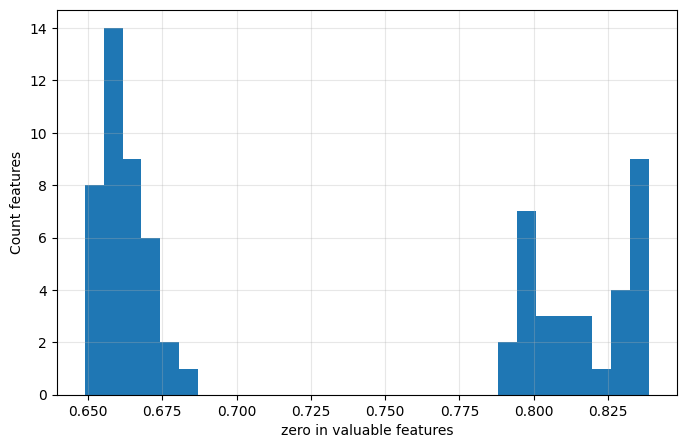

In [53]:
plt.figure(figsize=(8, 5))
plt.hist(zero_ratio_val_feats, bins=30)
plt.xlabel("zero in valuable features")
plt.ylabel("Count features")
plt.grid(True, alpha=0.3)
plt.show()

### Sparsity Conclusion
- __the dataset is strongly sparse: many columns are mostly zero and many rows contain few non-zero values__
- __this property is important for model choice and preprocessing__
- __the >=99% zero filter is a practical heuristic, but it should be checked against validation results before being treated as a final rule__

---
## Feature-Feature Analysis
---

In [54]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

In [55]:
len(to_drop)

30

In [56]:
top_corr_feats = X[to_drop].corr()

<Axes: >

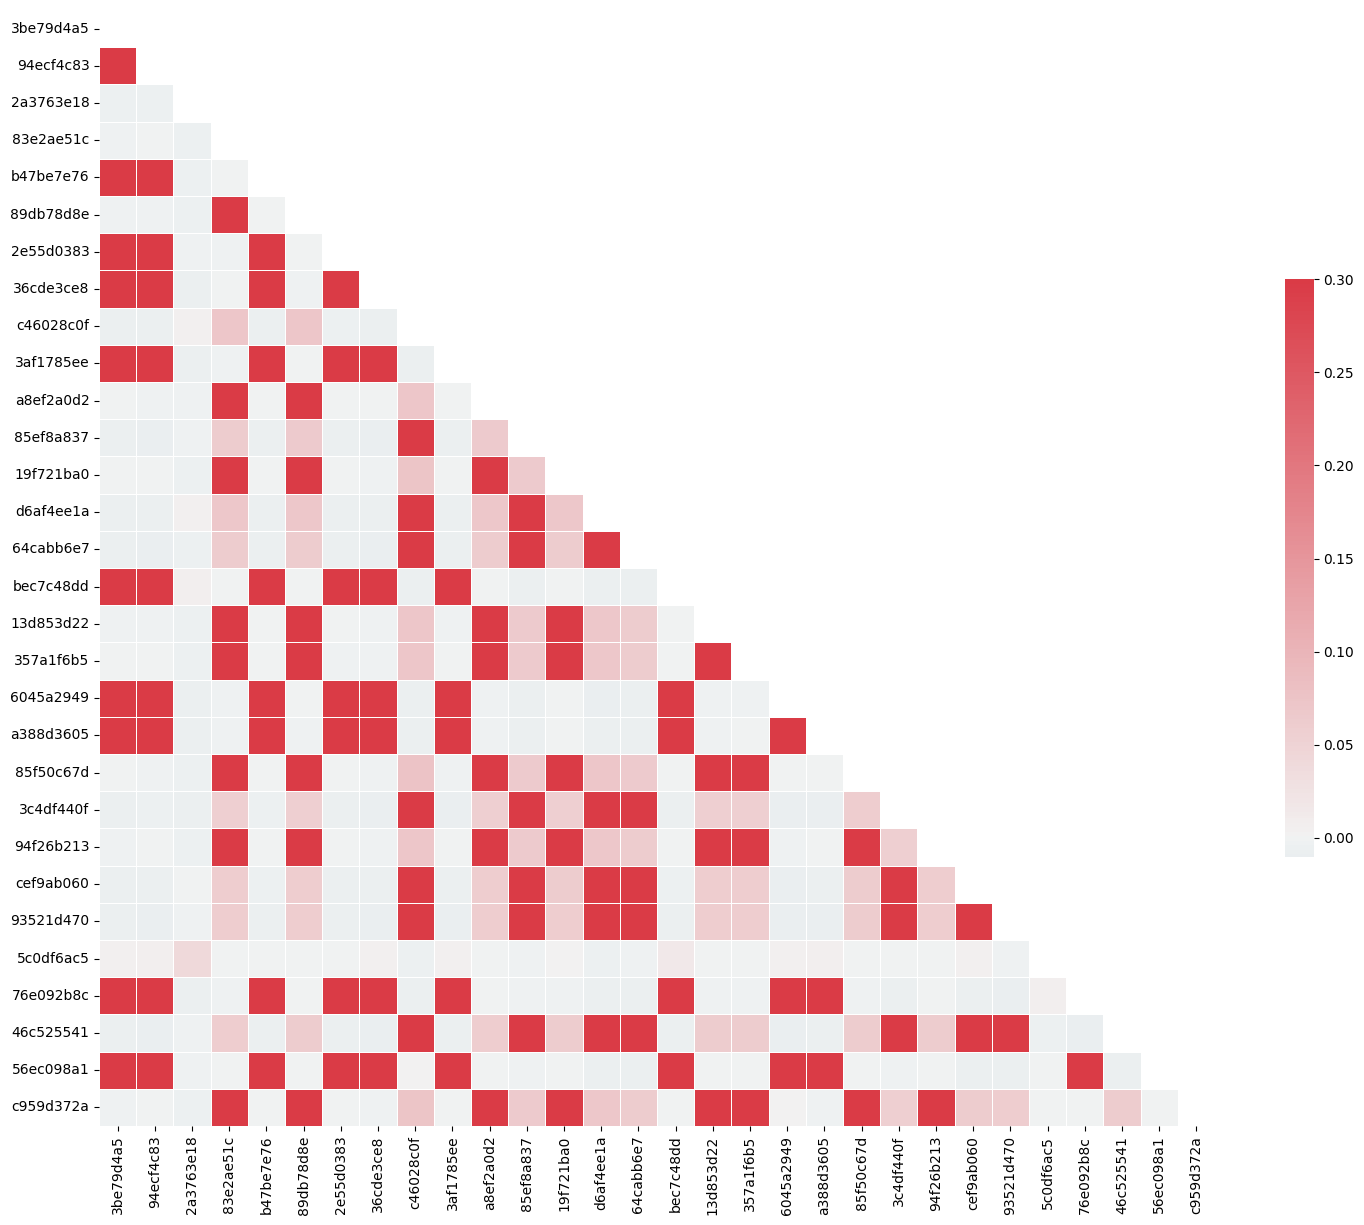

In [57]:
# display only top corrilated features
mask = np.zeros_like(top_corr_feats, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(18, 15))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(top_corr_feats, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

### Conclusion
- __about 30 features have high pairwise correlation under the selected threshold__ 
- __this may indicate redundant information, but the decision to drop them should depend on the downstream model and validation results__